In [1]:
import numpy as np
import matplotlib.pyplot as plt
from safety_formation.control_law.cbf import DecentralizedCBF
from safety_formation.formation import Agent,Topology

## Distributed ZCBF with slack variable

### Static Obstacle Avoidance

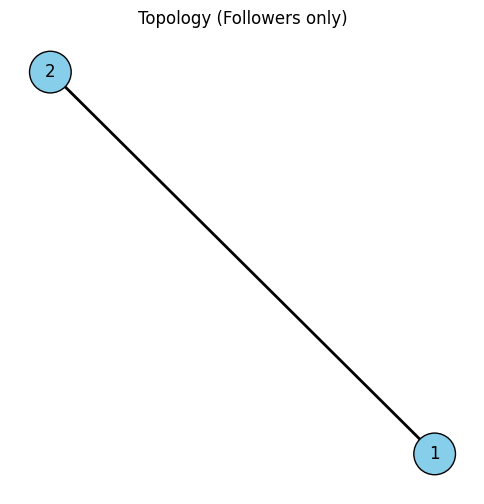

In [2]:
gamma = 0.5
d_min = 0.5

# State format: [x, y, vx, vy]
x_agent0  = [0.0,  0.0,  0.0, 0.0]
x_obs0    = [5.0, -0.05, 0.0, 0.0]
x_target  = np.array([10.0, 0.0, 0.0, 0.0], dtype=float)

alpha_agent = 6.0
alpha_obs   = 0.0   # static obstacle

# --- Create agents using your Agent class ---
# f_target is not used in this experiment, so set it to zeros
agent = Agent(agent_id=1, x0=x_agent0, f_target=[0, 0, 0, 0], alpha=alpha_agent)
obs   = Agent(agent_id=2, x0=x_obs0,   f_target=[0, 0, 0, 0], alpha=alpha_obs)

all_agents = [agent, obs]

# Save initial states if you want history from t=0
for ag in all_agents:
    ag.save_history()

# --- Create topology ---
# Agent and obstacle are connected so CBF checks safety constraint between them
adj = np.array([
    [0, 1],
    [1, 0]
], dtype=float)

topology = Topology(num_agents=2, adjacency_matrix=adj)
topology.plot()

# --- Create CBF filter ---
cbf_filter = DecentralizedCBF(gamma=gamma, safety_dis=d_min)

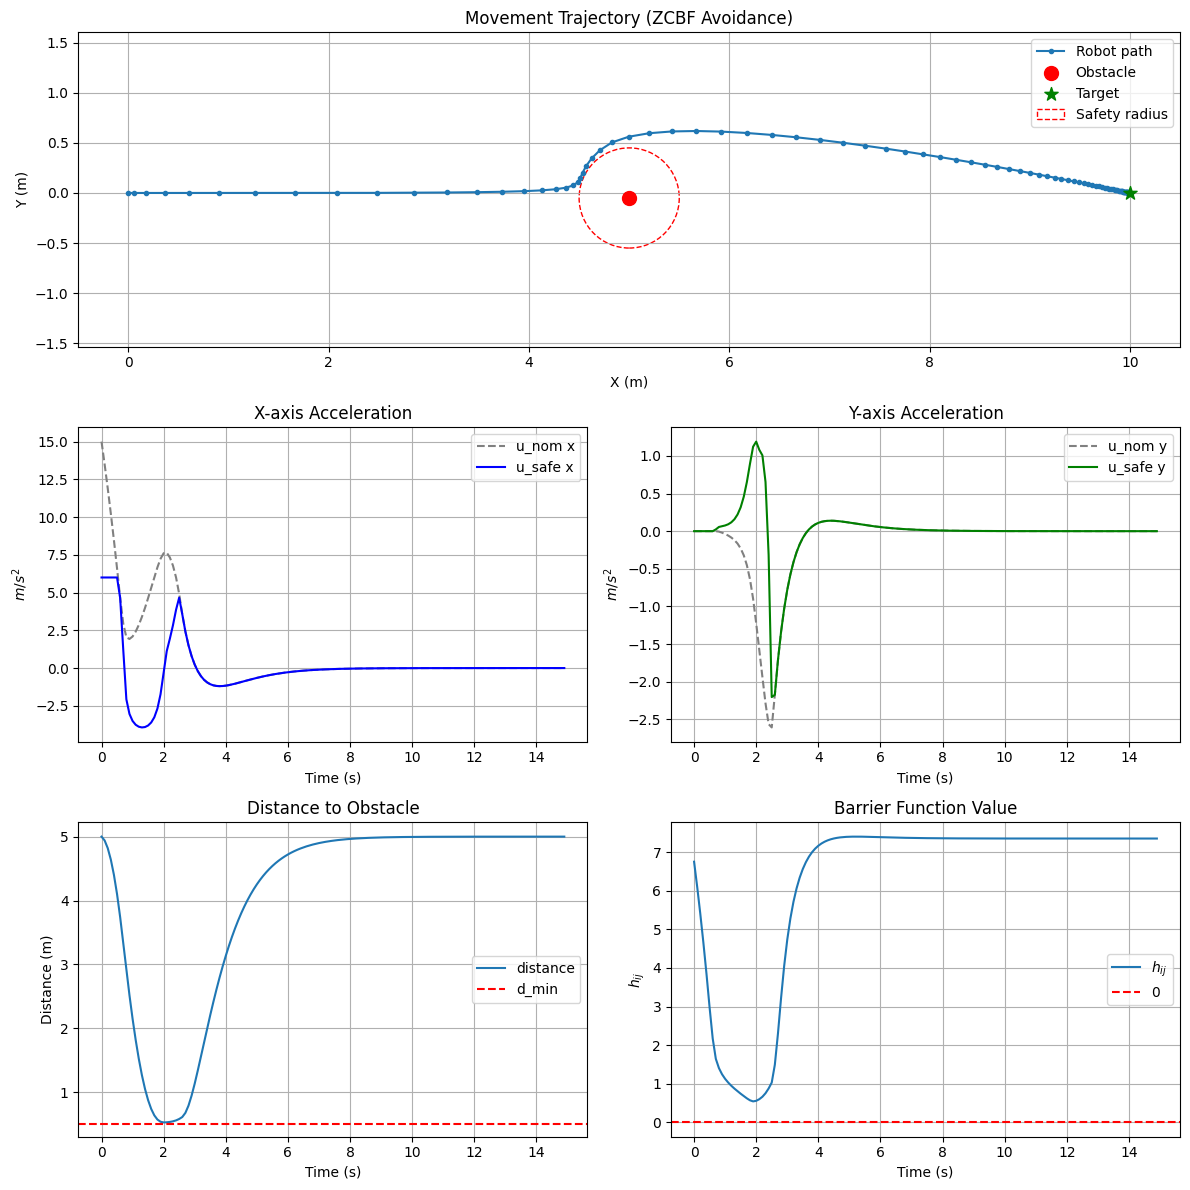

In [3]:
# --- History buffers ---
robot_history = []
u_hat_history = []
u_safe_history = []
h_history = []
dist_history = []

T = 15.0
dt = 0.1
steps = int(T / dt)

for k in range(steps):
    # Current robot state
    x_agent = agent.state.flatten()

    # 1) Nominal controller (PD-like tracking to target)
    u_hat = -1.5 * (agent.pos.flatten() - x_target[0:2]) - 2.5 * agent.vel.flatten()
    
    neighbor_list = topology.get_neighbors(1)
    
    # 3. Filter via Decentralized CBF
    # Only solves the QP for agent 1 locally
    u_nom_i = u_hat.reshape(2, 1)
    u_apply = cbf_filter.compute_safe_control(agent, 1, all_agents, neighbor_list, u_nom_i)
    u_apply = u_apply.flatten()

    # 4) Update physics
    # robot moves with safe input
    agent.update_physics(u_apply, dt)

    # obstacle stays fixed
    obs.update_physics([0.0, 0.0], dt)

    # 5) Store histories
    robot_history.append(agent.state.flatten())
    u_hat_history.append(u_hat.copy())
    u_safe_history.append(u_apply.copy())

    # Optional diagnostics: current distance and barrier-like quantity
    dp = agent.pos - obs.pos
    dv = agent.vel - obs.vel
    dist = max(np.linalg.norm(dp), 1e-6)
    dist_history.append(dist)

    # Avoid sqrt of negative when dist < d_min
    margin = max(dist - d_min, 1e-6)
    term_safe_v = np.sqrt(2 * (agent.alpha + obs.alpha) * margin)
    h_val = term_safe_v + float((dp.T @ dv).item()) / dist
    
    h_history.append(h_val)

# --- Convert histories to arrays ---
robot_history = np.array(robot_history)
u_hat_history = np.array(u_hat_history)
u_safe_history = np.array(u_safe_history)
dist_history = np.array(dist_history)
h_history = np.array(h_history)
time = np.arange(steps) * dt

# --- Plotting ---
fig = plt.figure(figsize=(12, 12))

# 1. Trajectory
ax1 = plt.subplot(3, 1, 1)
ax1.plot(robot_history[:, 0], robot_history[:, 1], '-o', markersize=3, label='Robot path')
ax1.scatter([x_obs0[0]], [x_obs0[1]], color='red', s=100, label='Obstacle', zorder=5)
ax1.scatter([x_target[0]], [x_target[1]], color='green', s=100, marker='*', label='Target', zorder=5)
circle = plt.Circle((x_obs0[0], x_obs0[1]), d_min, color='red', fill=False, linestyle='--', label='Safety radius')
ax1.add_patch(circle)
ax1.set_title("Movement Trajectory (ZCBF Avoidance)")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.axis("equal")
ax1.grid(True)
ax1.legend()

# 2. Control signals
ax2 = plt.subplot(3, 2, 3)
ax2.plot(time, u_hat_history[:, 0], '--', color='gray', label='u_nom x')
ax2.plot(time, u_safe_history[:, 0], '-', color='blue', label='u_safe x')
ax2.set_title("X-axis Acceleration")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"$m/s^2$")
ax2.grid(True)
ax2.legend()

ax3 = plt.subplot(3, 2, 4)
ax3.plot(time, u_hat_history[:, 1], '--', color='gray', label='u_nom y')
ax3.plot(time, u_safe_history[:, 1], '-', color='green', label='u_safe y')
ax3.set_title("Y-axis Acceleration")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel(r"$m/s^2$")
ax3.grid(True)
ax3.legend()

# 3. Distance to obstacle
ax4 = plt.subplot(3, 2, 5)
ax4.plot(time, dist_history, label='distance')
ax4.axhline(d_min, linestyle='--', color='red', label='d_min')
ax4.set_title("Distance to Obstacle")
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Distance (m)")
ax4.grid(True)
ax4.legend()

# 4. h_ij evolution
ax5 = plt.subplot(3, 2, 6)
ax5.plot(time, h_history, label=r'$h_{ij}$')
ax5.axhline(0.0, linestyle='--', color='red', label='0')
ax5.set_title("Barrier Function Value")
ax5.set_xlabel("Time (s)")
ax5.set_ylabel(r"$h_{ij}$")
ax5.grid(True)
ax5.legend()

plt.tight_layout()
plt.show()

### Collision Avoidance for Multi-agent System

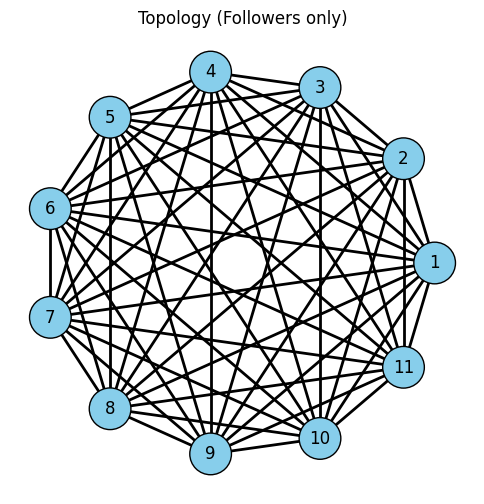

In [21]:
# --- Simulation Configuration ---
N = 11
R_circle = 150
dt = 0.1
T_max = 40
steps = int(T_max / dt)

gamma = 0.01
d_min = 18.0
k1, k2 = 1 , 2.8

alpha_val = 10.0
beta_val = 20.0

# --- Create agents using your Agent class ---
agents_list = []

for i in range(N):
    angle = 2 * np.pi * i / N

    # Initial state: [x, y, vx, vy]
    x0 = [
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ]

    # Opposite-side target
    target_pos = -np.array(x0[0:2]) - 10

    # f_target is not used in this experiment
    ag = Agent(
        agent_id=i + 1,
        x0=x0,
        f_target=[0.0, 0.0, 0.0, 0.0],
        alpha=alpha_val,
        beta=beta_val
    )

    # attach target for this experiment
    ag.target = target_pos.reshape(2,)
    agents_list.append(ag)

# --- Fully connected topology ---
adj_matrix = np.ones((N, N)) - np.eye(N)
topology = Topology(num_agents=N, adjacency_matrix=adj_matrix)

topology.plot()

# --- CBF filter ---
cbf_filter = DecentralizedCBF(gamma=gamma,k= 1, safety_dis=d_min)


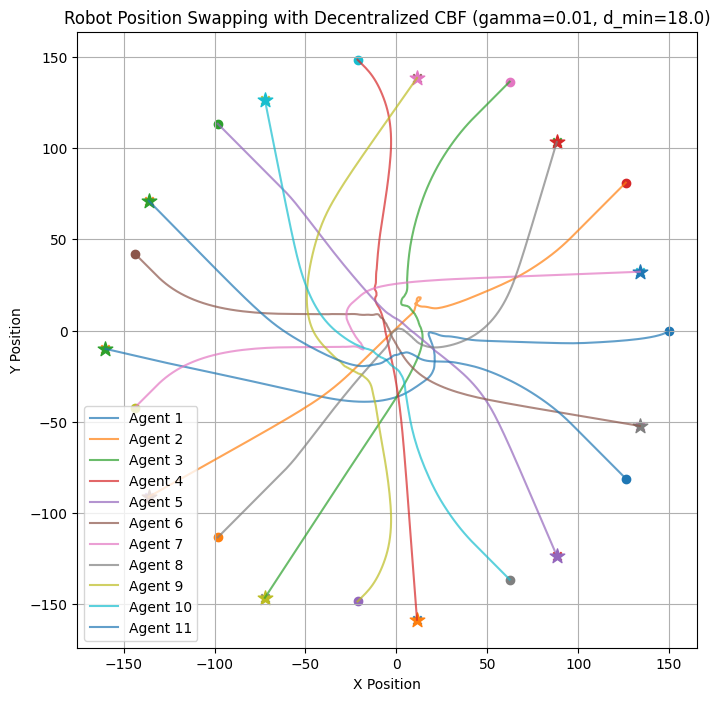

In [22]:
# --- History ---
history = [[] for _ in range(N)]
u_nom_hist = [[] for _ in range(N)]
u_safe_hist = [[] for _ in range(N)]

# --- Simulation Loop ---
for t in range(steps):
    u_nom_commands = {}
    u_safe_commands = {}

    # 1) Compute local safe control for each agent
    for agent_id in range(1, N + 1):
        current_agent = agents_list[agent_id - 1]   # because list is 0-based

        pos = current_agent.pos.flatten()
        vel = current_agent.vel.flatten()

        u_nom_i = -k1 * (pos - current_agent.target) - k2 * vel

        neighbor_list = topology.get_neighbors(agent_id)   # keep 1-based IDs

        u_safe_i = cbf_filter.compute_safe_control(
            agent_i=current_agent,
            agent_id=agent_id,
            all_agents=agents_list,        # list ordered by id
            neighbor_list=neighbor_list,
            u_nom_i=u_nom_i.reshape(2, 1)
        )

        u_nom_commands[agent_id] = u_nom_i.copy()
        u_safe_commands[agent_id] = u_safe_i.flatten()

    # 2) Update physics
    for agent_id in range(1, N + 1):
        ag = agents_list[agent_id - 1]

        ag.update_physics(u_safe_commands[agent_id], dt)

        history[agent_id - 1].append(ag.pos.flatten().copy())
        u_nom_hist[agent_id - 1].append(u_nom_commands[agent_id].copy())
        u_safe_hist[agent_id - 1].append(u_safe_commands[agent_id].copy())

# --- Convert history to arrays ---
history = [np.array(h) for h in history]
u_nom_hist = [np.array(h) for h in u_nom_hist]
u_safe_hist = [np.array(h) for h in u_safe_hist]

# --- Plot trajectories ---
plt.figure(figsize=(8, 8))
for i in range(N):
    traj = history[i]
    if len(traj) == 0:
        continue

    plt.plot(traj[:, 0], traj[:, 1], alpha=0.7, label=f'Agent {i+1}')
    plt.scatter(traj[0, 0], traj[0, 1], marker='o')
    plt.scatter(traj[-1, 0], traj[-1, 1], marker='x')
    plt.scatter(agents_list[i].target[0], agents_list[i].target[1], marker='*', s=120)

plt.title(f"Robot Position Swapping with Decentralized CBF (gamma={gamma}, d_min={d_min})")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
# # --- Plot control inputs (for debugging) ---
# time = np.arange(len(u_nom_hist[0])) * dt

# fig, axes = plt.subplots(N, 2, figsize=(10, 3*N))

# for i in range(N):
#     u_nom = u_nom_hist[i]
#     u_safe = u_safe_hist[i]

#     # X control
#     axes[i,0].plot(time, u_nom[:,0], '--', label='u_nom_x')
#     axes[i,0].plot(time, u_safe[:,0], '-', label='u_safe_x')
#     axes[i,0].set_title(f'Agent {i} - X acceleration')
#     axes[i,0].set_xlabel('Time (s)')
#     axes[i,0].set_ylabel('Acceleration')
#     axes[i,0].grid(True)
#     axes[i,0].legend()

#     # Y control
#     axes[i,1].plot(time, u_nom[:,1], '--', label='u_nom_y')
#     axes[i,1].plot(time, u_safe[:,1], '-', label='u_safe_y')
#     axes[i,1].set_title(f'Agent {i} - Y acceleration')
#     axes[i,1].set_xlabel('Time (s)')
#     axes[i,1].set_ylabel('Acceleration')
#     axes[i,1].grid(True)
#     axes[i,1].legend()

# plt.tight_layout()
# plt.show()

In [23]:
from matplotlib.animation import FFMpegWriter, FuncAnimation

# --- Reinitialize agents ---
agents_list = []
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N

    x0 = [
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ]

    target = -np.array(x0[0:2]) - 10

    # agent_id must be 1-based for your DecentralizedCBF
    ag = Agent(i + 1, x0, [0, 0, 0, 0], alpha=alpha_val, beta=beta_val)
    ag.target = target
    agents_list.append(ag)

# --- Fully connected topology ---
adj_matrix = np.ones((N, N)) - np.eye(N)
topology = Topology(num_agents=N, adjacency_matrix=adj_matrix)

# --- Decentralized CBF filter ---
cbf_filter = DecentralizedCBF(gamma=gamma, safety_dis=d_min)

# --- Animation figure ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title(f"{N} Robot Swapping - Decentralized CBF (gamma={gamma}, d_min={d_min})")

# plot targets
for ag in agents_list:
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]

# safety circles
circles = []
for ag in agents_list:
    c = plt.Circle(
        (ag.pos[0, 0], ag.pos[1, 0]),
        d_min / 2,
        fill=False,
        linestyle="--",
        alpha=0.5
    )
    ax.add_patch(c)
    circles.append(c)

info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# --- Update function ---
def update(frame):
    u_safe_commands = {}

    # compute local safe control for each agent
    for agent_id in range(1, N + 1):
        ag = agents_list[agent_id - 1]

        pos = ag.pos.flatten()
        vel = ag.vel.flatten()

        u_nom_i = -k1 * (pos - ag.target) - k2 * vel
        u_nom_i = np.clip(u_nom_i, -ag.alpha, ag.alpha)

        neighbor_list = topology.get_neighbors(agent_id)  # keep 1-based ids

        u_safe_i = cbf_filter.compute_safe_control(
            agent_i=ag,
            agent_id=agent_id,
            all_agents=agents_list,
            neighbor_list=neighbor_list,
            u_nom_i=u_nom_i.reshape(2, 1)
        )

        u_safe_commands[agent_id] = u_safe_i.flatten()

    # physics update
    for agent_id in range(1, N + 1):
        ag = agents_list[agent_id - 1]
        ag.update_physics(u_safe_commands[agent_id], dt)

        history[agent_id - 1].append(ag.pos.flatten().copy())
        traj = np.array(history[agent_id - 1])

        x = ag.pos[0, 0]
        y = ag.pos[1, 0]

        points[agent_id - 1].set_data([x], [y])
        trails[agent_id - 1].set_data(traj[:, 0], traj[:, 1])
        circles[agent_id - 1].center = (x, y)

    info_text.set_text(f"Time: {frame * dt:.1f}s")
    return points + trails + circles + [info_text]

# --- Render video ---
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

writer = FFMpegWriter(fps=int(1 / dt), bitrate=2000)
ani.save("decentralized_cbf_validation.mp4", writer=writer)

plt.close(fig)

print("Video saved: decentralized_cbf_validation.mp4")

Video saved: decentralized_cbf_validation.mp4


## Relax Distributed CBF

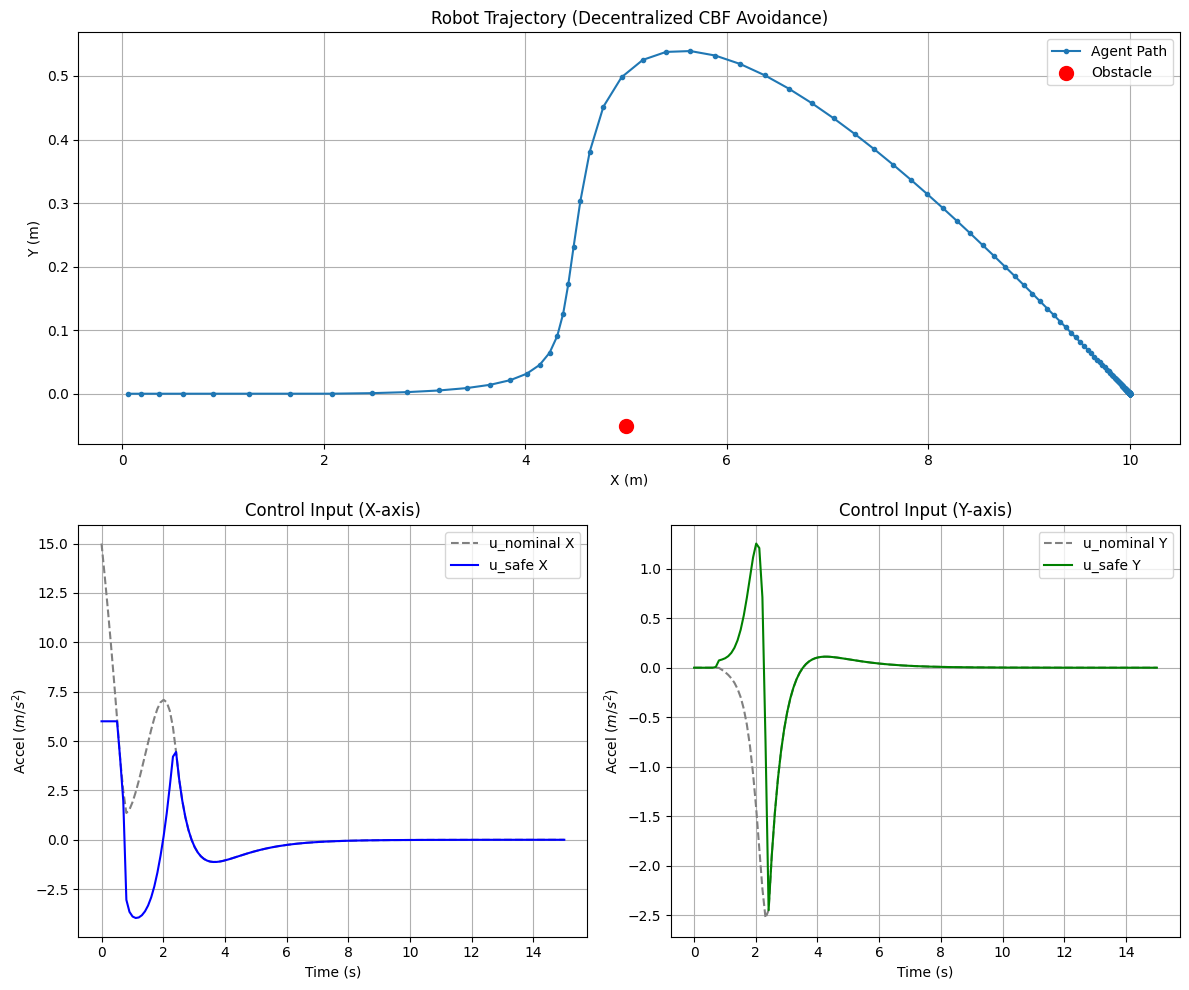

In [8]:
# --- Simulation Configuration ---
dt = 0.1
T = 15.0 
steps = int(T / dt)
gamma = 1.0     # CBF relaxation parameter
d_min = 0.5     # Minimum safety distance (m)

# Agent and Obstacle Initial States: [x, y, vx, vy]
x_agent = np.array([0.0, 0.0, 0.0, 0.0]) 
x_obs = np.array([5.0, -0.05, 0.0, 0.0]) # Static obstacle slightly off-center
x_target = np.array([10.0, 0.0, 0.0, 0.0])

alpha_agent = 6.0 # Max acceleration for the agent
alpha_obs = 0.0   # Static obstacle has no acceleration capability

# Data logging
history = []
u_hat_history = []
u_safe_history = []

# Initialize the Decentralized CBF filter
cbf_filter = DecentralizedCBF(gamma=gamma, safety_dis=d_min)

for k in range(steps):
    # 1. Compute Nominal Control (PD Controller)
    # Drives the agent toward target while damping oscillations
    u_hat = -1.5 * (x_agent[0:2] - x_target[0:2]) - 2.5 * x_agent[2:4]
    
    # 2. Mock Agent Data for the Filter
    # In decentralized mode, the filter needs the state of neighbors
    class MockAgent:
        def __init__(self, pos, vel, alpha, id):
            self.pos = pos
            self.vel = vel
            self.alpha = alpha
            self.id = id

    a1 = MockAgent(x_agent[0:2], x_agent[2:4], alpha_agent, 1)
    a2 = MockAgent(x_obs[0:2], x_obs[2:4], alpha_obs, 2)
    
    # All agents in the environment (needed for neighbor lookup)
    all_agents = {1: a1, 2: a2}
    neighbor_list = [2] # Agent 1 detects Obstacle 2
    
    # 3. Filter via Decentralized CBF
    # Only solves the QP for agent 1 locally
    u_nom_i = u_hat.reshape(2, 1)
    u_apply = cbf_filter.compute_relax_safe_control(a1, 1, all_agents, neighbor_list, u_nom_i)
    
    # Handle QP failure (fallback to zero acceleration/braking)
    if u_apply is not None:
        u_apply = u_apply.flatten()
    else:
        u_apply = np.array([0.0, 0.0])

    # Log control inputs
    u_hat_history.append(u_hat.copy())
    u_safe_history.append(u_apply.copy())

    # 4. Update Physics (Euler Integration)
    # v = v + a*dt, p = p + v*dt
    x_agent[2:4] += u_apply * dt
    x_agent[0:2] += x_agent[2:4] * dt
    history.append(x_agent.copy())

# --- Visualization ---
history = np.array(history)
u_hat_history = np.array(u_hat_history)
u_safe_history = np.array(u_safe_history)
time = np.linspace(0, T, steps)

fig = plt.figure(figsize=(12, 10))

# Plot Trajectory
ax1 = plt.subplot(2, 1, 1)
ax1.plot(history[:, 0], history[:, 1], '-o', markersize=3, label='Agent Path')
ax1.scatter([x_obs[0]], [x_obs[1]], color='red', s=100, label='Obstacle', zorder=5)
ax1.set_title("Robot Trajectory (Decentralized CBF Avoidance)")
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)")
ax1.legend(); ax1.grid(True)

# Plot Control Input X
ax2 = plt.subplot(2, 2, 3)
ax2.plot(time, u_hat_history[:, 0], '--', color='gray', label='u_nominal X')
ax2.plot(time, u_safe_history[:, 0], '-', color='blue', label='u_safe X')
ax2.set_title("Control Input (X-axis)")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Accel ($m/s^2$)")
ax2.legend(); ax2.grid(True)

# Plot Control Input Y
ax3 = plt.subplot(2, 2, 4)
ax3.plot(time, u_hat_history[:, 1], '--', color='gray', label='u_nominal Y')
ax3.plot(time, u_safe_history[:, 1], '-', color='green', label='u_safe Y')
ax3.set_title("Control Input (Y-axis)")
ax3.set_xlabel("Time (s)"); ax3.set_ylabel("Accel ($m/s^2$)")
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plt.show()

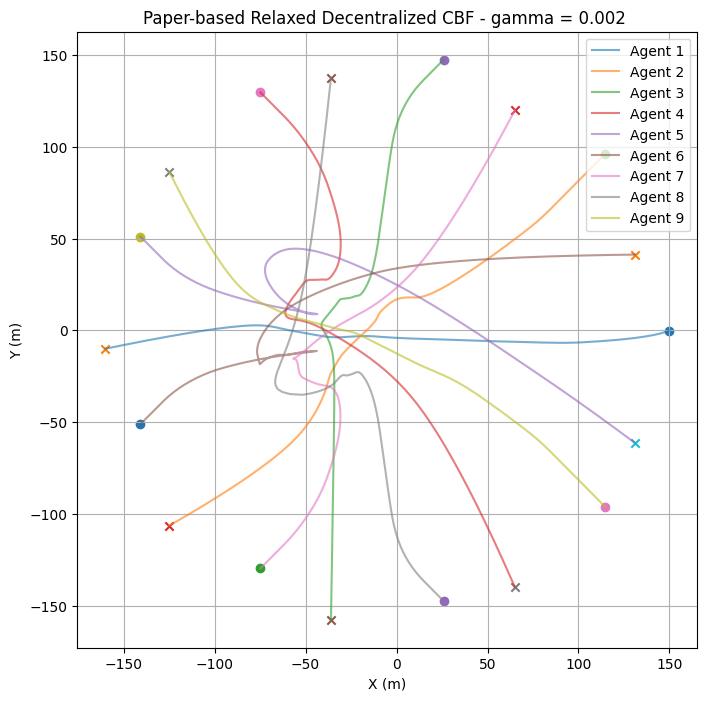

In [9]:
# --- Simulation Configuration ---
N = 9               # Number of agents
R_circle = 150      # Circle radius
dt = 0.1
T_max = 50          # Simulation time
gamma = 0.002         # CBF relaxation (higher = tighter avoidance)
d_min = 20.0        # Safety distance (Ds)
k1, k2 = 1.0, 2.0   # PD controller gains

# --- Agent Class for Simulation ---
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = pos
        self.vel = np.zeros(2)
        self.target = target
        self.alpha = 20.0  # Max acceleration limit

# --- Initialize Agents ---
agents_dict = {}
for i in range(N):
    angle = 2 * np.pi * i / N
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)])
    target = -pos -10 # Goal is exactly on the opposite side
    agents_dict[i] = AgentObj(i, pos, target)

# Initialize the Decentralized CBF filter
cbf_filter = DecentralizedCBF(gamma=gamma, safety_dis=d_min)

# Data logging
history = [[] for _ in range(N)]

# --- Simulation Loop ---
for t in range(int(T_max/dt)):
    # In decentralized control, each agent performs its own computation
    u_safe_commands = {}
    
    for i in range(N):
        current_agent = agents_dict[i]
        
        # 1. Compute Nominal Control (Nominal "Wish")
        u_nom_i = -k1 * (current_agent.pos - current_agent.target) - k2 * current_agent.vel
        u_nom_i = u_nom_i.reshape(2, 1)
        
        # 2. Identify Neighbors (In this case, all other agents)
        neighbor_list = [j for j in range(N) if i != j]
        
        # 3. Apply Decentralized CBF Filter
        # This solves a local 2x2 QP for Agent i
        u_safe_i = cbf_filter.compute_relax_safe_control(
            current_agent, i, agents_dict, neighbor_list, u_nom_i
        )
        
        if u_safe_i is not None:
            u_safe_commands[i] = u_safe_i.flatten()
        else:
            u_safe_commands[i] = np.zeros(2) # Fallback to stop

    # 4. Physical Update (Sync step: apply all movements after calculation)
    for i in range(N):
        ag = agents_dict[i]
        ag.vel += u_safe_commands[i] * dt
        ag.pos += ag.vel * dt
        history[i].append(ag.pos.copy())

# --- Plotting Results ---
plt.figure(figsize=(8,8))
for i in range(N):
    traj = np.array(history[i])
    plt.plot(traj[:,0], traj[:,1], alpha=0.6, label=f'Agent {i+1}')
    plt.scatter(traj[0,0], traj[0,1], marker='o') # Start
    plt.scatter(traj[-1,0], traj[-1,1], marker='x') # End

plt.title("Paper-based Relaxed Decentralized CBF - gamma = 0.002 ")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# --- 1. Simulation Configuration ---
N = 9              # Number of agents
R_circle = 150      # Radius
dt = 0.1            # Time step
T_max = 19          # Increased time to allow agents to reach targets
gamma = 0.002         # Lower gamma for smoother decentralized response
d_min = 20.0        # Safety distance (Ds)
k1, k2 = 1.0, 2.0   # PD gains

# --- 2. Define Agent Class (Compatible with DecentralizedCBF) ---
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = np.array(pos, dtype=float)
        self.vel = np.zeros(2, dtype=float)
        self.target = np.array(target, dtype=float)
        self.alpha = 20.0  # Max acceleration

# --- 3. Initialize State ---
agents_dict = {} # Using a dict for easier ID lookup in decentralized mode
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)], dtype=float)
    target = -pos - 10# Perfect swap
    agents_dict[i] = AgentObj(i, pos, target)

# Initialize the DECENTRALIZED filter
cbf_filter = DecentralizedCBF(gamma=gamma, safety_dis=d_min)

# --- 4. Setup Plotting ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title(" Paper-based Relaxed Decentralized CBF - gamma = 0.002 ")

for ag in agents_dict.values():
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# --- 5. Decentralized Update Function ---
def update(frame):
    global agents_dict, history
    
    u_safe_commands = {}

    # Each agent computes its own control independently
    for i in range(N):
        ag = agents_dict[i]
        
        # a. Local Nominal Control (Wish)
        u_nom_i = -k1 * (ag.pos - ag.target) - k2 * ag.vel
        u_nom_i = u_nom_i.reshape(2, 1)
        
        # b. Identify Neighbors (In this case, all others)
        neighbor_list = [j for j in range(N) if i != j]
        
        # c. Local CBF Filter (Solves a 2x2 QP per agent)
        u_safe_i = cbf_filter.compute_relax_safe_control(ag, i, agents_dict, neighbor_list, u_nom_i)
        # u_safe_i = u_nom_i
        
        if u_safe_i is not None:
            u_safe_commands[i] = u_safe_i.flatten()
        else:
            u_safe_commands[i] = np.array([0, 0]) # Fallback if QP fails

    # d. Synchronous Physics Update
    for i in range(N):
        ag = agents_dict[i]
        ag.vel += u_safe_commands[i] * dt
        ag.pos += ag.vel * dt
        
        history[i].append(ag.pos.copy())
        traj = np.array(history[i])
        points[i].set_data([ag.pos[0]], [ag.pos[1]])
        trails[i].set_data(traj[:, 0], traj[:, 1])

    info_text.set_text(f"Time: {frame*dt:.1f}s | Relax Decentralized Mode")
    return points + trails + [info_text]

# --- 6. Rendering ---
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

print("Rendering decentralized_cbf_validation.mp4...")
try:
    writer = FFMpegWriter(fps=int(1/dt), bitrate=2000)
    ani.save("relax_decentralized_cbf_validation.mp4", writer=writer)
    print("Success! Decentralized validation video created.")
except Exception as e:
    print(f"Error: {e}")

plt.close(fig)

Rendering decentralized_cbf_validation.mp4...
Error: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '800x800', '-pix_fmt', 'rgba', '-framerate', '10', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-b', '2000k', '-y', 'relax_decentralized_cbf_validation.mp4']' returned non-zero exit status 255.
